In [2]:
# 1. SETUP Y VALIDACION DE HARDWARE
# Se instalan las librerias requeridas de forma silenciosa para mantener limpia la consola.
# Se incluye Ultralytics para el modelo YOLO y kagglehub para la descarga del dataset.

!pip install -q ultralytics kagglehub

import torch
import ultralytics
import kagglehub
import os

# Se ejecuta la comprobacion interna de Ultralytics para asegurar que las dependencias base esten correctas.

ultralytics.checks()

# Se realiza una verificacion critica de infraestructura.
# El entrenamiento de modelos de vision computacional requiere aceleracion por hardware.

if torch.cuda.is_available():
    print(f"\n[INFO] Aceleracion por GPU detectada y asignada: {torch.cuda.get_device_name(0)}")
else:
    print("\n[ALERTA] No se detecta aceleracion por GPU.")
    print("Accion requerida: Cambiar el tipo de entorno de ejecucion a 'T4 GPU' en las configuraciones de la plataforma para asegurar tiempos de entrenamiento viables.")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)

[INFO] Aceleracion por GPU detectada y asignada: Tesla T4


In [3]:
# 2. INGESTA Y EXPLORACION INICIAL DEL DATASET

print("\n[INFO] Iniciando la descarga del dataset desde repositorios publicos...")

# Se descarga el dataset directamente al entorno temporal sin exponer credenciales de acceso.

dataset_path = kagglehub.dataset_download("yusufmurtaza01/grape-leaf-diseases")
print(f"[INFO] Descarga completada exitosamente. Ruta local definida en: {dataset_path}\n")

print("[INFO] Analisis de la topologia del directorio:")

# Se itera sobre el arbol de directorios para mapear la estructura de los datos crudos.

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * level
    folder_name = os.path.basename(root) if os.path.basename(root) else "Directorio_Raiz"
    print(f"{indent}- {folder_name}/")

    subindent = ' ' * 4 * (level + 1)

    # Se limita la visualizacion a los primeros tres archivos por subcarpeta para mantener la legibilidad.

    if files:
        for f in files[:3]:
            print(f"{subindent}* {f}")
        if len(files) > 3:
            print(f"{subindent}... y {len(files) - 3} archivos adicionales omitidos en esta vista.")


[INFO] Iniciando la descarga del dataset desde repositorios publicos...


100%|██████████| 143M/143M [00:00<00:00, 177MB/s]

Extracting files...


[INFO] Descarga completada exitosamente. Ruta local definida en: /root/.cache/kagglehub/datasets/yusufmurtaza01/grape-leaf-diseases/versions/1

[INFO] Analisis de la topologia del directorio:
- 1/
    * grape_dataset_labels_plot.png
    * grape_dataset_images_plot.png
    - grape/
        * data.yaml
        - labels/
            - val/
                * pv_GRLB_image (373).txt
                * pv_GRBR_image (738).txt
                * pv_GRHE_image (131).txt
                ... y 834 archivos adicionales omitidos en esta vista.
            - train/
                * pv_GRBR_image (975).txt
                * pv_GRBR_image (1161).txt
                * pv_GRES_image (600).txt
                ... y 3355 archivos adicionales omitidos en esta vista.
        - images/
            - val/
                * pv_GRBR_image (1068).jpg
                * pv_GRBR_image (65).jpg
                * pv_GRLB_image (667).jpg
                ... y 834 archivos adicionales omitidos en esta vista.
          

In [4]:
# 3. CONFIGURACION DE RUTAS Y PREPARACION DE DATOS

import yaml
import os

# Se define la ruta base del dataset dentro del entorno temporal.

base_path = "/root/.cache/kagglehub/datasets/yusufmurtaza01/grape-leaf-diseases/versions/1/grape"
yaml_path = os.path.join(base_path, "data.yaml")

print("[INFO] Inspeccionando archivo de configuracion original (data.yaml)...")

# Se lee la estructura del archivo de configuracion original.

with open(yaml_path, 'r') as file:
    data_config = yaml.safe_load(file)

print(f"[INFO] Clases identificadas en el dataset: {data_config.get('names', [])}")
print(f"[INFO] Total de clases (nc): {data_config.get('nc', 0)}")

# Se actualizan las llaves del diccionario para establecer rutas absolutas.
# Esto asegura la resolucion correcta de las imagenes durante el pipeline de entrenamiento.

data_config['path'] = base_path
data_config['train'] = "images/train"
data_config['val'] = "images/val"

# Se elimina la referencia a la carpeta de pruebas (test) si existe,
# dado que la topologia previa mostro unicamente directorios de entrenamiento y validacion.

if 'test' in data_config:
    del data_config['test']

# Se reescribe el archivo de configuracion con los parametros corregidos.
with open(yaml_path, 'w') as file:
    yaml.dump(data_config, file, default_flow_style=False)

print("[INFO] Actualizacion completada. El archivo data.yaml esta preparado para el modelo.")

[INFO] Inspeccionando archivo de configuracion original (data.yaml)...
[INFO] Clases identificadas en el dataset: ['Grape__BlackRot', 'Grape__Esca', 'Grape__Healthy', 'Grape__LeafBlight']
[INFO] Total de clases (nc): 4
[INFO] Actualizacion completada. El archivo data.yaml esta preparado para el modelo.


In [5]:
# 4. ENTRENAMIENTO DEL MODELO (YOLOv8 Nano)

from ultralytics import YOLO

# Se define la ruta del archivo de configuracion preparado en la etapa anterior.

yaml_path = "/root/.cache/kagglehub/datasets/yusufmurtaza01/grape-leaf-diseases/versions/1/grape/data.yaml"

# Se instancia la arquitectura del modelo.
# Se selecciona la version 'nano' (yolov8n.pt) por su bajo peso computacional,
# optimizada para despliegues en dispositivos de borde con restricciones de hardware.

print("[INFO] Inicializando arquitectura YOLOv8n...")
model = YOLO("yolov8n.pt")

# Se ejecuta el proceso de entrenamiento del modelo.
# Parametros configurados para una prueba de concepto rapida y eficiente:
# - epochs=25: Balance adecuado entre tiempo de computo y observacion de convergencia.
# - imgsz=640: Resolucion estandar que mantiene integridad visual sin saturar la VRAM.
# - batch=32: Maximizacion del uso de la GPU T4 asignada por el entorno.
# - patience=5: Control de sobreajuste mediante detencion temprana si no hay mejora.
# - seed=42: Fijacion de la semilla aleatoria para garantizar reproducibilidad.

print("[INFO] Iniciando pipeline de entrenamiento. Este proceso puede tomar varios minutos...")

results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=32,
    patience=5,
    project="grape_disease_poc",
    name="yolov8n_triage",
    seed=42,
    device=0
)

print("[INFO] Pipeline de entrenamiento concluido. Artefactos y metricas almacenados en el directorio del proyecto.")

[INFO] Inicializando arquitectura YOLOv8n...
[INFO] Iniciando pipeline de entrenamiento. Este proceso puede tomar varios minutos...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/yusufmurtaza01/grape-leaf-diseases/versions/1/grape/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

[INFO] Configurando motor de inferencia...
[INFO] Modo Fast-Track activado. Esperando la carga del archivo (.pt)...


Saving best.pt to best.pt
[INFO] Artefacto cargado exitosamente en el entorno: best.pt
[INFO] Seleccionando muestra aleatoria del conjunto de validacion...
[INFO] Ejecutando predicciones sobre la muestra...


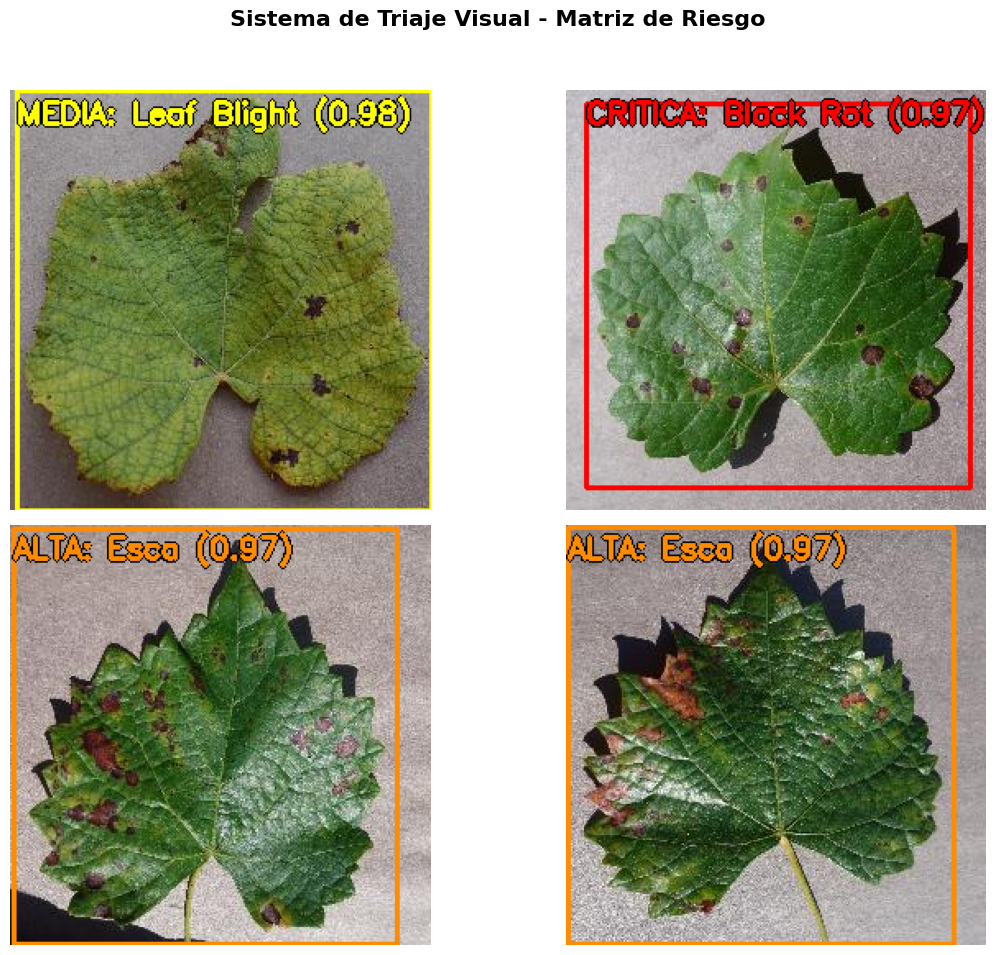

[INFO] Renderizado granular de triaje completado.


In [19]:
# 5. INFERENCIA Y CAPA DE PRESENTACION DE NEGOCIO (TRIAJE GRANULAR)

# @title Opciones de Inferencia (Fast-Track)
# @markdown Seleccione el origen de los pesos del modelo antes de ejecutar la celda:

origen_modelo = "Subir_Pesos_Manualmente" # @param ["Modelo_Recien_Entrenado", "Subir_Pesos_Manualmente"]

import glob
import random
import matplotlib.pyplot as plt
import cv2
import os
from ultralytics import YOLO

print("[INFO] Configurando motor de inferencia...")

# RESOLUCION DINAMICA DEL ARTEFACTO (PESOS DEL MODELO)

model_path = ""

if origen_modelo == "Subir_Pesos_Manualmente":
    from google.colab import files
    print("[INFO] Modo Fast-Track activado. Esperando la carga del archivo (.pt)...")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("[ALERTA CRITICA] No se subio ningun archivo. Ejecucion abortada.")

    model_path = list(uploaded.keys())[0]
    print(f"[INFO] Artefacto cargado exitosamente en el entorno: {model_path}")
else:
    model_path = "/content/runs/detect/grape_disease_poc/yolov8n_triage/weights/best.pt"
    if not os.path.exists(model_path):
        raise FileNotFoundError("[ALERTA CRITICA] No se encontro un modelo en cache. Ejecute la Celda 4 o cambie el modo a 'Subir_Pesos_Manualmente'.")

print("[INFO] Seleccionando muestra aleatoria del conjunto de validacion...")
val_images_path = "/root/.cache/kagglehub/datasets/yusufmurtaza01/grape-leaf-diseases/versions/1/grape/images/val/*.jpg"
image_files = glob.glob(val_images_path)

if not image_files:
    print("[ALERTA] No se encontraron imagenes en el directorio especificado.")
else:
    sample_images = random.sample(image_files, min(4, len(image_files)))

    # Se instancia el modelo con la ruta resuelta dinamicamente
    triage_model = YOLO(model_path)

    print("[INFO] Ejecutando predicciones sobre la muestra...")
    results = triage_model.predict(source=sample_images, conf=0.25, save=False, verbose=False)

    # CAPA DE APLICACION: MATRIZ DE RIESGO Y RENDERIZADO VISUAL

    business_triage_mapping = {
        0: ('CRITICA: Black Rot', (255, 0, 0)),
        1: ('ALTA: Esca', (255, 140, 0)),
        2: ('SANO: Sin anomalias', (0, 255, 0)),
        3: ('MEDIA: Leaf Blight', (255, 255, 0))
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Sistema de Triaje Visual - Matriz de Riesgo", fontsize=16, fontweight='bold')

    for i, r in enumerate(results):
        img = r.orig_img.copy()
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if r.boxes is not None:
            for box in r.boxes:
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

                label_text, color_rgb = business_triage_mapping.get(cls_id, ('Desconocido', (255, 255, 255)))
                display_text = f"{label_text} ({conf:.2f})"

                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color_rgb, 2)
                text_y = max(20, y1 - 10)
                cv2.putText(img_rgb, display_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
                cv2.putText(img_rgb, display_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_rgb, 2)

        ax = axes[i//2, i%2]
        ax.imshow(img_rgb)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("[INFO] Renderizado granular de triaje completado.")

In [20]:
#  6. INTERFAZ INTERACTIVA DE PROTOTIPADO (MVP)

# Se instala la libreria Gradio para la generacion de interfaces web de prototipado rapido.
!pip install -q gradio

import gradio as gr
import cv2
import numpy as np
from ultralytics import YOLO

print("[INFO] Inicializando entorno de prototipado rapido con Gradio...")

# CONFIGURACION DEL MOTOR Y REGLAS DE NEGOCIO

# Se asume que la ejecucion previa resolvio la ubicacion del artefacto (.pt)

try:
    model_path_mvp = model_path if 'model_path' in locals() and model_path else "/content/runs/detect/grape_disease_poc/yolov8n_triage/weights/best.pt"
    triage_model_mvp = YOLO(model_path_mvp)
except Exception as e:
    print("[ALERTA] No se encontro el modelo en cache. Valide la ruta del artefacto.")

business_triage_mapping = {
    0: ('CRITICA: Black Rot', (255, 0, 0)),
    1: ('ALTA: Esca', (255, 140, 0)),
    2: ('SANO: Sin anomalias', (0, 255, 0)),
    3: ('MEDIA: Leaf Blight', (255, 255, 0))
}

# FUNCION DE INFERENCIA PARA LA INTERFAZ

def predict_triage_gradio(image):
    """
    Recibe un array numpy (RGB) desde la interfaz web, ejecuta el motor de
    inferencia YOLO, aplica las reglas de negocio y retorna la imagen procesada.
    """
    if image is None:
        return None

    # YOLO ejecuta la prediccion. conf=0.25 establece el umbral de confianza base.
    results = triage_model_mvp.predict(source=image, conf=0.25, save=False, verbose=False)

    # Se genera una copia del input para no alterar el array original de la interfaz
    img_output = image.copy()

    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

                label_text, color_rgb = business_triage_mapping.get(cls_id, ('Desconocido', (255, 255, 255)))
                display_text = f"{label_text} ({conf:.2f})"

                # Renderizado visual de cajas y etiquetas con borde de contraste
                cv2.rectangle(img_output, (x1, y1), (x2, y2), color_rgb, 2)
                text_y = max(20, y1 - 10)
                cv2.putText(img_output, display_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
                cv2.putText(img_output, display_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_rgb, 2)

    return img_output

# ---------------------------------------------------------
# DESPLIEGUE DE LA INTERFAZ WEB
# ---------------------------------------------------------
# Se estructura la aplicacion web con un diseño limpio y orientado al usuario final
demo = gr.Interface(
    fn=predict_triage_gradio,
    inputs=gr.Image(type="numpy", label="Input Operativo: Suba una imagen capturada en campo"),
    outputs=gr.Image(type="numpy", label="Output de Negocio: Matriz de Riesgo (Triaje)"),
    title="MVP - Sistema de Triaje Visual (Edge AI)",
    description="Prueba de concepto interactiva. Suba una imagen de una hoja de vid para evaluar en tiempo real la aplicacion de reglas de negocio sobre la prediccion del modelo YOLOv8 Nano.",
    allow_flagging="never"
)

print("[INFO] Desplegando interfaz web publica. Haga clic en el enlace 'public URL' a continuacion:")
demo.launch(share=True, debug=False)

[INFO] Inicializando entorno de prototipado rapido con Gradio...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


[INFO] Desplegando interfaz web publica. Haga clic en el enlace 'public URL' a continuacion:
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6ef850a2c4152103ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
